# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## Research Question

Can observable content and search signals be used to prioritize pages for human review when deciding which content may be worth refreshing?

This project focuses on the **Refresh / Content Opportunity Scoring** lane.

### Decision supported

The analysis produces a ranked list of content items that can be reviewed by an editor or content strategist.

The output is intended to answer:

> Which pages should a human review first, and what signal explains why they were prioritized?

The unit of analysis is an individual pseudonymized content item.

The system does not automatically modify, publish, delete, or redirect content.

A wrong positive recommendation may cause an editor to spend time reviewing a page that does not need attention. A wrong negative recommendation may cause a potentially useful content opportunity to receive attention later.

The goal is therefore **decision support and prioritization**, not automated content decisions or prediction of Google's ranking algorithm.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*



The analysis uses the anonymized FlyRank content dataset.

The dataset contains:

- **30,000 content records**
- **44 columns**
- Five observed `trend_direction` classes

### Target distribution

| Trend direction | Records |
|---|---:|
| down | 16,262 |
| stable | 5,962 |
| up | 4,388 |
| new | 2,236 |
| flat | 1,152 |

The `down` class is the largest class, representing approximately 51.1% of the dataset.

### Data exclusions

The following fields were deliberately excluded from predictive features:

- `trend_direction` — this is the target label
- `trend_pct` — directly related to the target trend
- `content_id` — pseudonymous content identifier
- `client_id` — pseudonymous client identifier and used only for grouped validation

For the strict leakage audit, additional performance variables were excluded because they are closely connected to the observed performance outcome:

- `impressions_90d`
- `clicks_90d`
- `pageviews_90d`
- `sessions_90d`
- `users_90d`
- `engaged_sessions_90d`
- `ai_sessions_90d`
- `scroll_events_90d`
- `days_with_impressions`
- `days_with_sessions`
- `impressions_last_30d`
- `clicks_last_30d`
- `sessions_last_30d`
- `impressions_prev_30d`
- `clicks_prev_30d`
- `sessions_prev_30d`
- `ctr`
- `avg_position`
- `engagement_rate`
- `scroll_rate`
- `ai_traffic_pct`
- `impression_tier`
- `position_tier`

The strict model therefore uses only features that remain after this leakage-focused exclusion.

In [ ]:
# ============================================================
# 2. DATA — LOAD AND INSPECT
# ============================================================

import pandas as pd
import numpy as np

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "acecod3z/Flyrankinternship/main/"
    "data/raw/content_refresh_anonymized.csv"
)

df = pd.read_csv(DATA_URL)

print("Dataset shape:", df.shape)

print("\nTarget distribution:")
print(df["trend_direction"].value_counts())

print("\nTarget percentages:")
print(
    (df["trend_direction"].value_counts(normalize=True) * 100)
    .round(2)
)

Dataset shape: (30000, 44)

Target distribution:
trend_direction
down      16262
stable     5962
up         4388
new        2236
flat       1152
Name: count, dtype: int64

Target percentages:
trend_direction
down      54.21
stable    19.87
up        14.63
new        7.45
flat       3.84
Name: proportion, dtype: float64


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*


### Target

The target is `trend_direction`, an observed categorical label with five classes:

`down`, `stable`, `up`, `new`, and `flat`.

The model is therefore treated as a five-class classification problem.

### Validation design

The final evaluation uses a **client-grouped 80/20 split**.

Records belonging to the same client are kept on the same side of the split. This prevents the model from being evaluated on records from clients it has already seen during training.

The split uses `random_state=42` for reproducibility.

The resulting split contains:

- 23,837 training records
- 6,163 testing records
- 25 training clients
- 7 testing clients
- 0 client overlap

### Model

The final model is a Random Forest classifier.

Random Forest was selected because it can represent nonlinear relationships and interactions between content characteristics while also providing feature-importance information for interpretation.

### Leakage controls

The target and target-derived fields were removed before training.

Pseudonymous IDs were also removed from the feature matrix. `client_id` is retained separately only for creating the grouped validation split.

A strict leakage audit was performed after feature construction. The audit confirmed that the target, trend percentage, content ID, and client ID were not present in the final feature matrix.

### Baseline

For the final classification comparison, a simple majority-class baseline is included. It always predicts the most common class in the training data.

This provides a transparent lower-complexity reference point for judging whether the learned model provides useful classification beyond simply predicting the most frequent class.

The earlier Week-5 random split is also retained as a validation-design comparison, but the client-grouped result is treated as the more conservative estimate.

In [ ]:
# ============================================================
# 3. METHODOLOGY — FEATURES + CLIENT-GROUPED SPLIT
# ============================================================

from sklearn.model_selection import GroupShuffleSplit

target = "trend_direction"

# Columns excluded from the strict model
excluded_columns = [
    "trend_direction",
    "trend_pct",
    "content_id",
    "client_id",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
    "impression_tier",
    "position_tier"
]

excluded_columns = [
    col for col in excluded_columns
    if col in df.columns
]

X = df.drop(columns=excluded_columns).copy()
y = df[target].copy()

# ------------------------------------------------------------
# Client-grouped split
# ------------------------------------------------------------

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        X,
        y,
        groups=df["client_id"]
    )
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_clients = set(
    df.iloc[train_idx]["client_id"]
)

test_clients = set(
    df.iloc[test_idx]["client_id"]
)

client_overlap = train_clients.intersection(
    test_clients
)

print("Training rows :", len(X_train))
print("Testing rows  :", len(X_test))
print("Training clients:", len(train_clients))
print("Testing clients :", len(test_clients))
print("Client overlap  :", len(client_overlap))

assert len(client_overlap) == 0

print("\nClient-grouped split: PASS")

Training rows : 23837
Testing rows  : 6163
Training clients: 25
Testing clients : 7
Client overlap  : 0

Client-grouped split: PASS


In [ ]:
# ============================================================
# 3. METHODOLOGY — PREPROCESSING + RANDOM FOREST
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

numeric_cols = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(handle_unknown="ignore")
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_cols
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_cols
    )
])

rf_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        )
    )
])

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

print("Random Forest training complete.")
print("Number of input features:", X_train.shape[1])

Random Forest training complete.
Number of input features: 17


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*



The final comparison uses the same client-grouped test set for both the majority-class baseline and the Random Forest.

The majority-class baseline always predicts the most frequent training class. This establishes the minimum simple reference point.

The earlier Week-5 random split produced 78.75% accuracy and 76.82% weighted F1. After moving to client-grouped validation, performance decreased to 72.40% accuracy and 69.35% weighted F1.

The stricter leakage-safe model removes performance variables that were potentially adjacent to the observed trend outcome. Under this stricter feature set, the Random Forest achieved 43.01% accuracy and 38.21% weighted F1.

This reduction is treated as an important validation finding rather than hidden. It shows that feature selection and validation design materially affect the apparent performance of the model.

In [ ]:
# ============================================================
# 4. RESULTS — MODEL VS MAJORITY BASELINE
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

# ------------------------------------------------------------
# Majority-class baseline
# ------------------------------------------------------------

majority_class = y_train.mode()[0]

baseline_pred = np.full(
    len(y_test),
    majority_class
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred,
    average="weighted"
)

# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="weighted"
)

# ------------------------------------------------------------
# Comparison table
# ------------------------------------------------------------

comparison = pd.DataFrame([
    {
        "Model": "Majority Baseline",
        "Accuracy": baseline_accuracy,
        "Weighted F1": baseline_f1
    },
    {
        "Model": "Strict Random Forest",
        "Accuracy": rf_accuracy,
        "Weighted F1": rf_f1
    }
])

comparison[
    ["Accuracy", "Weighted F1"]
] = comparison[
    ["Accuracy", "Weighted F1"]
].round(4)

display(comparison)

print("Majority class:", majority_class)
print(
    "Test-set base rate:",
    round(
        y_test.value_counts(normalize=True).max(),
        4
    )
)

print("\nRandom Forest classification report:")
print(
    classification_report(
        y_test,
        rf_pred
    )
)

,Model,Accuracy,Weighted F1
0,Majority Baseline,0.5110,0.3456
1,Strict Random Forest,0.4301,0.3821


Majority class: down
Test-set base rate: 0.511

Random Forest classification report:
              precision    recall  f1-score   support

        down       0.51      0.72      0.60      3149
        flat       0.24      0.04      0.06       382
         new       0.10      0.09      0.09       302
      stable       0.29      0.19      0.23      1301
          up       0.17      0.09      0.11      1029

    accuracy                           0.43      6163
   macro avg       0.26      0.22      0.22      6163
weighted avg       0.37      0.43      0.38      6163



In [ ]:
# ============================================================
# 4. RESULTS — VALIDATION DESIGN COMPARISON
# ============================================================

validation_comparison = pd.DataFrame([
    {
        "Validation": "Week-5 Random Split",
        "Accuracy": 0.7875,
        "Weighted F1": 0.7682
    },
    {
        "Validation": "Week-6 Client-Grouped Split",
        "Accuracy": 0.7240,
        "Weighted F1": 0.6935
    },
    {
        "Validation": "Strict Leakage-Safe Split",
        "Accuracy": rf_accuracy,
        "Weighted F1": rf_f1
    }
])

validation_comparison[
    ["Accuracy", "Weighted F1"]
] = validation_comparison[
    ["Accuracy", "Weighted F1"]
].round(4)

display(validation_comparison)

,Validation,Accuracy,Weighted F1
0,Week-5 Random Split,0.7875,0.7682
1,Week-6 Client-Grouped Split,0.7240,0.6935
2,Strict Leakage-Safe Split,0.4301,0.3821


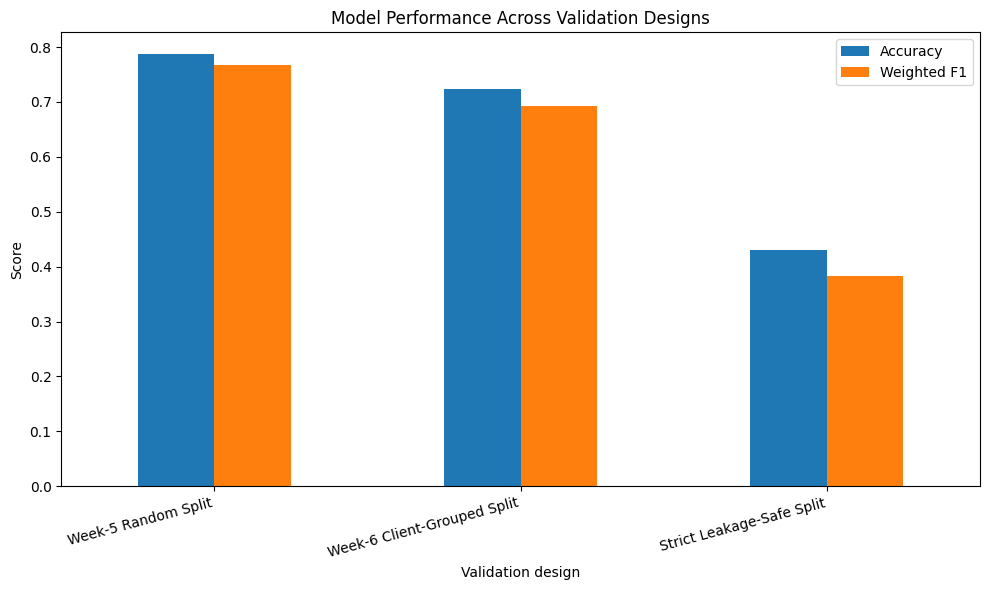

In [ ]:
# ============================================================
# VALIDATION PERFORMANCE CHART
# ============================================================

import matplotlib.pyplot as plt

ax = validation_comparison.set_index(
    "Validation"
)[["Accuracy", "Weighted F1"]].plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    "Model Performance Across Validation Designs"
)

ax.set_xlabel(
    "Validation design"
)

ax.set_ylabel(
    "Score"
)

plt.xticks(
    rotation=15,
    ha="right"
)

plt.tight_layout()

plt.show()

## 5. Limitations

*What this work cannot claim.*



The results should be interpreted as observed and directional evidence rather than proof of future performance.

### 1. Observational target

`trend_direction` is an observed label. The model does not establish that a content change causes a page to move from one trend category to another.

### 2. Class imbalance

The `down` class represents approximately 51.1% of the dataset. Accuracy must therefore be interpreted alongside the class distribution and weighted F1.

### 3. Validation sensitivity

The model's apparent performance changes substantially depending on the validation design and feature set.

The Week-5 random split produced 78.75% accuracy and 76.82% weighted F1. Client-grouped validation reduced this to 72.40% accuracy and 69.35% weighted F1. The stricter leakage-safe feature set produced 43.01% accuracy and 38.21% weighted F1.

This demonstrates why the stricter evaluation is used for the final interpretation.

### 4. Generalization

The client-grouped test set contains seven clients that were not present in training. The result therefore provides evidence about this particular unseen-client split, not a guarantee of performance on every future client or dataset.

### 5. No causal claim

The model identifies patterns associated with the observed data. It does not prove that refreshing a page will improve traffic, clicks, rankings, or engagement.

### 6. No Google algorithm claim

The analysis does not predict, reproduce, or establish Google's ranking algorithm.

### Appropriate interpretation

The final system should therefore be used as **decision-support for prioritizing human review**.

A high score or predicted trend category should be treated as a signal to investigate, not as an instruction to automatically change content.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*



The action playbook converts the model output into a ranked review queue for content editors. The purpose is decision support: it helps prioritize which content should be reviewed first rather than automatically deciding what should be changed.

### Priority 1 — Refresh declining, highly visible content

The highest-priority action is **REFRESH_CONTENT** for content with a strong model probability of belonging to the `down` trend category and evidence of meaningful recent visibility.

The associated reason code is `DECLINING_HIGH_VISIBILITY`.

These pages are useful review candidates because they combine observed visibility with a directional decline signal. An editor should inspect the page, search intent, content freshness, competing results, and recent performance before deciding whether a refresh is appropriate.

### Priority 2 — Review declining content with weaker visibility

Content with a high probability of declining but lower visibility should receive a lower review priority. These cases may still be useful opportunities, but the potential value of intervention is less clear from the available measurements.

### Priority 3 — Monitor stable or uncertain content

Stable or uncertain predictions should generally be monitored rather than immediately changed. The model is not evidence that an intervention will improve performance.

### Archetype-to-action mapping

| Observed situation | Suggested action | Reason |
|---|---|---|
| High predicted probability of `down` + meaningful visibility | Refresh content | Potentially important declining content |
| Predicted `down` + limited visibility | Review / monitor | Lower measured opportunity |
| `stable` or uncertain prediction | Monitor | Insufficient evidence for immediate intervention |
| `up` | Protect / monitor | Avoid unnecessary changes to improving content |
| `new` | Monitor | Limited historical evidence |
| `flat` | Monitor / review | Direction is less clearly actionable |

### How an editor could use the queue

The ranked queue should be treated as a starting point for human review. An editor can begin with the highest-ranked items, inspect the supporting measurements and reason code, and then decide whether to refresh, monitor, protect, or take no action.

The ranking provides prioritization rather than a guaranteed outcome. In particular, a high model probability does not establish that refreshing a page will cause its performance to improve.

### Confidence and limits

The strongest evidence in this project is that the model can rank observed content into different review priorities on the evaluated dataset. Under client-grouped validation, performance was lower than under the earlier random split, so the ranked output should be treated conservatively when applied to unseen clients.

The recommendations are therefore **decision-support suggestions**, not automated editorial decisions or causal predictions.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

GENERATING PAPER ARTIFACTS


<Figure size 1000x600 with 0 Axes>

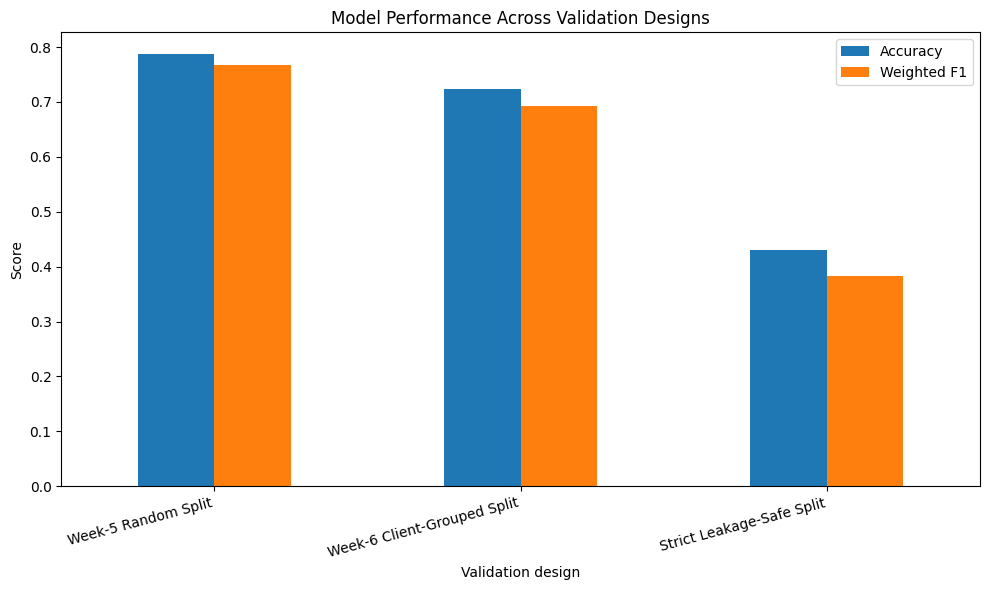

Saved: work/figures/capstone_validation_comparison.png


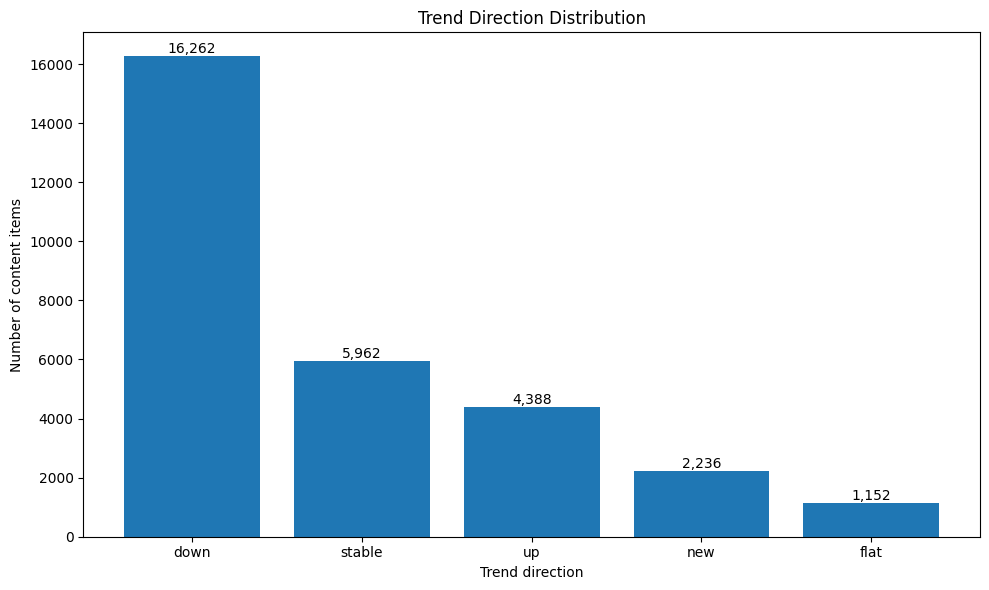

Saved: work/figures/capstone_trend_distribution.png

MODEL VALIDATION COMPARISON


,Validation,Accuracy,Weighted F1
0,Week-5 Random Split,0.7875,0.7682
1,Week-6 Client-Grouped Split,0.7240,0.6935
2,Strict Leakage-Safe Split,0.4301,0.3821



ARTIFACT INVENTORY
PASS  work/figures/capstone_validation_comparison.png (102,846 bytes)
CHECK work/figures/capstone_feature_importance.png (not found)
PASS  work/figures/capstone_trend_distribution.png (72,378 bytes)
CHECK work/outputs/w07_ranked_action_queue.csv (not found)
CHECK work/outputs/w07_action_playbook_metrics.json (not found)
CHECK work/outputs/w08_recommendation_summary.csv (not found)

Paper artifacts generated.


In [ ]:
# ============================================================
# 7. ARTIFACTS THE PAPER EMBEDS
# ============================================================

import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create output directories
os.makedirs("work/figures", exist_ok=True)
os.makedirs("work/outputs", exist_ok=True)

print("=" * 60)
print("GENERATING PAPER ARTIFACTS")
print("=" * 60)


# ------------------------------------------------------------
# 1. Validation comparison chart
# ------------------------------------------------------------

if "validation_comparison" in globals():

    plt.figure(figsize=(10, 6))

    validation_comparison.set_index(
        "Validation"
    )[["Accuracy", "Weighted F1"]].plot(
        kind="bar",
        figsize=(10, 6)
    )

    plt.title(
        "Model Performance Across Validation Designs"
    )

    plt.xlabel(
        "Validation design"
    )

    plt.ylabel(
        "Score"
    )

    plt.xticks(
        rotation=15,
        ha="right"
    )

    plt.tight_layout()

    validation_path = (
        "work/figures/capstone_validation_comparison.png"
    )

    plt.savefig(
        validation_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Saved:",
        validation_path
    )


# ------------------------------------------------------------
# 2. Random Forest feature importance chart
# ------------------------------------------------------------

# Use the importance dataframe created earlier if available.
# Otherwise calculate it from the Random Forest model.

importance_df = None

if "importance" in globals():

    importance_df = importance.copy()

elif "rf" in globals() and "X_train" in globals():

    importance_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": rf.feature_importances_
    })

if importance_df is not None:

    importance_df = importance_df.sort_values(
        "Importance",
        ascending=False
    ).head(10)

    plt.figure(figsize=(10, 6))

    plt.barh(
        importance_df["Feature"][::-1],
        importance_df["Importance"][::-1]
    )

    plt.title(
        "Top 10 Random Forest Features"
    )

    plt.xlabel(
        "Feature importance"
    )

    plt.ylabel(
        "Feature"
    )

    plt.tight_layout()

    importance_path = (
        "work/figures/capstone_feature_importance.png"
    )

    plt.savefig(
        importance_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Saved:",
        importance_path
    )


# ------------------------------------------------------------
# 3. Trend direction distribution
# ------------------------------------------------------------

if "df" in globals() and "trend_direction" in df.columns:

    trend_counts = (
        df["trend_direction"]
        .value_counts()
        .reindex(
            ["down", "stable", "up", "new", "flat"]
        )
        .fillna(0)
    )

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        trend_counts.index,
        trend_counts.values
    )

    plt.title(
        "Trend Direction Distribution"
    )

    plt.xlabel(
        "Trend direction"
    )

    plt.ylabel(
        "Number of content items"
    )

    # Add counts above bars
    for bar, value in zip(
        bars,
        trend_counts.values
    ):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{int(value):,}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()

    distribution_path = (
        "work/figures/capstone_trend_distribution.png"
    )

    plt.savefig(
        distribution_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.show()

    print(
        "Saved:",
        distribution_path
    )


# ------------------------------------------------------------
# 4. Paper-safe model comparison table
# ------------------------------------------------------------

if "validation_comparison" in globals():

    paper_comparison = validation_comparison.copy()

    print("\nMODEL VALIDATION COMPARISON")
    display(paper_comparison)


# ------------------------------------------------------------
# 5. Paper-safe recommendation summary
# ------------------------------------------------------------

if "queue" in globals():

    recommendation_summary = (
        queue["action"]
        .value_counts()
        .rename_axis("Action")
        .reset_index(name="Count")
    )

    print("\nRECOMMENDATION SUMMARY")
    display(recommendation_summary)

    recommendation_summary.to_csv(
        "work/outputs/w08_recommendation_summary.csv",
        index=False
    )

    print(
        "Saved: work/outputs/w08_recommendation_summary.csv"
    )


# ------------------------------------------------------------
# 6. Artifact inventory
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ARTIFACT INVENTORY")
print("=" * 60)

expected_files = [
    "work/figures/capstone_validation_comparison.png",
    "work/figures/capstone_feature_importance.png",
    "work/figures/capstone_trend_distribution.png",
    "work/outputs/w07_ranked_action_queue.csv",
    "work/outputs/w07_action_playbook_metrics.json",
    "work/outputs/w08_recommendation_summary.csv"
]

for file_path in expected_files:

    if os.path.exists(file_path):

        file_size = os.path.getsize(file_path)

        print(
            f"PASS  {file_path} "
            f"({file_size:,} bytes)"
        )

    else:

        print(
            f"CHECK {file_path} "
            f"(not found)"
        )

print("\nPaper artifacts generated.")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.